In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded = files.upload()

Saving 01 Retail Inventory.xlsx to 01 Retail Inventory.xlsx


In [6]:
df = pd.read_excel('01 Retail Inventory.xlsx')

In [7]:
df.head()

,Product ID,Product Name,Category,Supplier Name,Unit Cost,Retail Price,Opening Stock,Units Sold,Closing Stock,Reorder Point,Stock Status
0,PRD-1001,Wine Glasses,Home & Kitchen,Heritage Brands,23.78,38.89,135,118,17,30,Low Stock
1,PRD-1002,Eye Mask,Beauty,Coastal Trading,15.67,24.53,86,10,76,9,In Stock
2,PRD-1003,Resistance Band,Sports & Outdoors,National Supply Group,5.59,11.88,319,195,124,47,In Stock
3,PRD-1004,Action Figure,Toys & Games,Pacific Wholesale,9.72,18.01,173,140,33,39,Low Stock
4,PRD-1005,Serving Tray,Home & Kitchen,Coastal Trading,8.22,13.90,32,8,24,7,In Stock


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product ID     1000 non-null   object 
 1   Product Name   1000 non-null   object 
 2   Category       1000 non-null   object 
 3   Supplier Name  1000 non-null   object 
 4   Unit Cost      1000 non-null   float64
 5   Retail Price   1000 non-null   float64
 6   Opening Stock  1000 non-null   int64  
 7   Units Sold     1000 non-null   int64  
 8   Closing Stock  1000 non-null   int64  
 9   Reorder Point  1000 non-null   int64  
 10  Stock Status   1000 non-null   object 
dtypes: float64(2), int64(4), object(5)
memory usage: 86.1+ KB


In [9]:
df.isnull().sum()

,0
Product ID,0
Product Name,0
Category,0
Supplier Name,0
Unit Cost,0
Retail Price,0
Opening Stock,0
Units Sold,0
Closing Stock,0
Reorder Point,0


In [10]:
df.describe()

,Unit Cost,Retail Price,Opening Stock,Units Sold,Closing Stock,Reorder Point
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,16.061210,27.976780,262.451000,137.040000,125.411000,44.98300
std,14.172094,24.915064,140.104457,103.623232,99.023521,27.54468
min,0.520000,1.070000,20.000000,3.000000,4.000000,2.00000
25%,7.035000,11.962500,141.750000,53.000000,44.000000,22.00000
50%,12.430000,21.760000,261.000000,108.500000,96.000000,41.00000
75%,20.775000,35.307500,388.000000,204.000000,190.000000,64.25000
max,78.790000,157.400000,499.000000,463.000000,432.000000,119.00000


In [11]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.drop_duplicates(inplace=True)

In [16]:
df['Opening Stock']

,Opening Stock
0,135
1,86
2,319
3,173
4,32
...,...
995,25
996,175
997,147
998,144


In [17]:
df['Category'].value_counts()

,count
Category,
Beauty,134
Sports & Outdoors,132
Electronics,126
Office Supplies,126
Home & Kitchen,124
Toys & Games,123
Grocery,119
Clothing,116


In [18]:
df.groupby('Category')['Units Sold'].sum()

,Units Sold
Category,
Beauty,18137
Clothing,13736
Electronics,17621
Grocery,15364
Home & Kitchen,18387
Office Supplies,17112
Sports & Outdoors,16979
Toys & Games,19704


In [19]:
top_products = df.groupby('Product Name')['Units Sold'].sum().sort_values(ascending=False).head(10)

print(top_products)

Product Name
Power Bank       3162
Eye Mask         3111
Spice Rack       2815
Coloring Set     2798
Dried Fruit      2619
Highlighters     2610
Action Figure    2530
Hand Cream       2512
Stapler          2501
Utensil Set      2487
Name: Units Sold, dtype: int64


In [22]:
low_stock = df.sort_values(by='Opening Stock').head(10)

print(low_stock)

    Product ID     Product Name           Category          Supplier Name  \
786   PRD-1787      Canvas Belt           Clothing     AllGoods Supply Co   
389   PRD-1390       Hair Brush             Beauty    Premier Merchandise   
6     PRD-1007        Dish Soap     Home & Kitchen      Pacific Wholesale   
19    PRD-1020      Dry Shampoo             Beauty        Heritage Brands   
698   PRD-1699          Whistle  Sports & Outdoors   Global Source Direct   
420   PRD-1421   Coffee Mug Set     Home & Kitchen      Pacific Wholesale   
614   PRD-1615     Puzzle 500pc       Toys & Games   Global Source Direct   
838   PRD-1839  Resistance Band  Sports & Outdoors  National Supply Group   
574   PRD-1575        Golf Tees  Sports & Outdoors     AllGoods Supply Co   
819   PRD-1820      Notebook A5    Office Supplies        Coastal Trading   

     Unit Cost  Retail Price  Opening Stock  Units Sold  Closing Stock  \
786      21.01         36.23             20          13              7   
389 

In [24]:
df.groupby('Supplier Name')['Opening Stock'].sum()

,Opening Stock
Supplier Name,
AllGoods Supply Co,18775
Coastal Trading,28346
Global Source Direct,27149
Heritage Brands,29666
Metro Distributors,23406
National Supply Group,29566
Pacific Wholesale,23445
Premier Merchandise,32441
Summit Wholesale Inc,24694


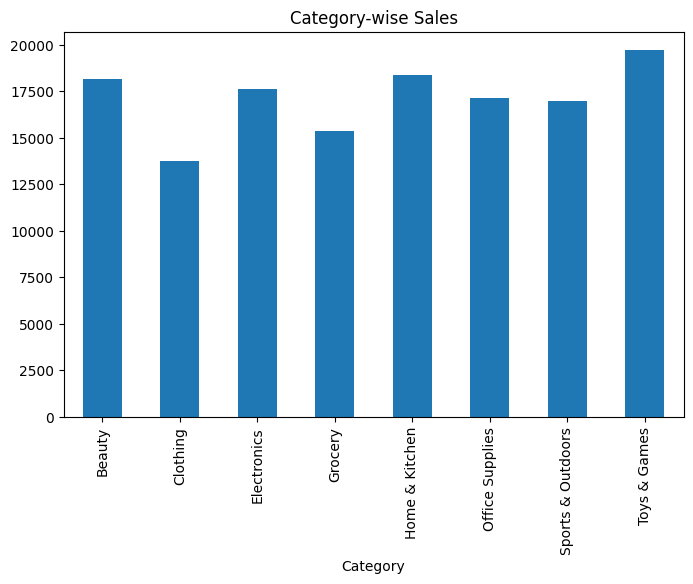

In [25]:
category_sales = df.groupby('Category')['Units Sold'].sum()

category_sales.plot(kind='bar', figsize=(8,5))
plt.title('Category-wise Sales')
plt.show()

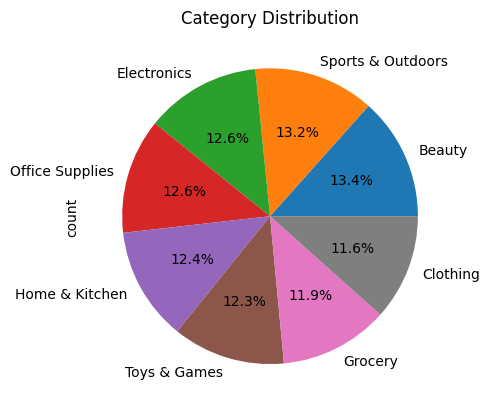

In [26]:
df['Category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Category Distribution')
plt.show()

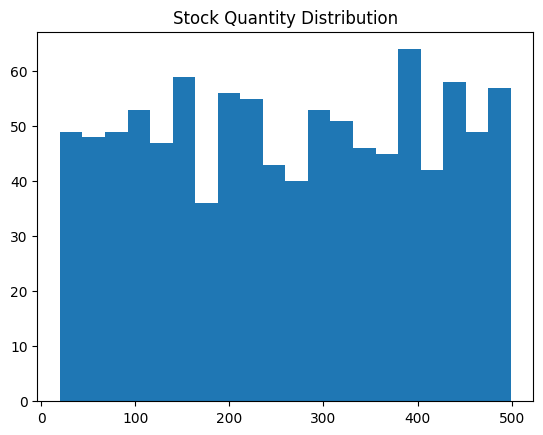

In [28]:
plt.hist(df['Opening Stock'], bins=20)
plt.title('Stock Quantity Distribution')
plt.show()

Electronics and selected high-performing products have the highest sales, indicating strong customer demand in these categories.

Several products are at or below their reorder point, indicating immediate restocking is required to avoid stockouts.

Some products show low unit sales despite available stock, indicating slow-moving inventory that may require promotional strategies.

A few suppliers contribute a large portion of inventory, creating dependency risk if supply chain disruptions occur.

Certain products have high closing stock but low sales, indicating overstocking and inefficient inventory allocation.

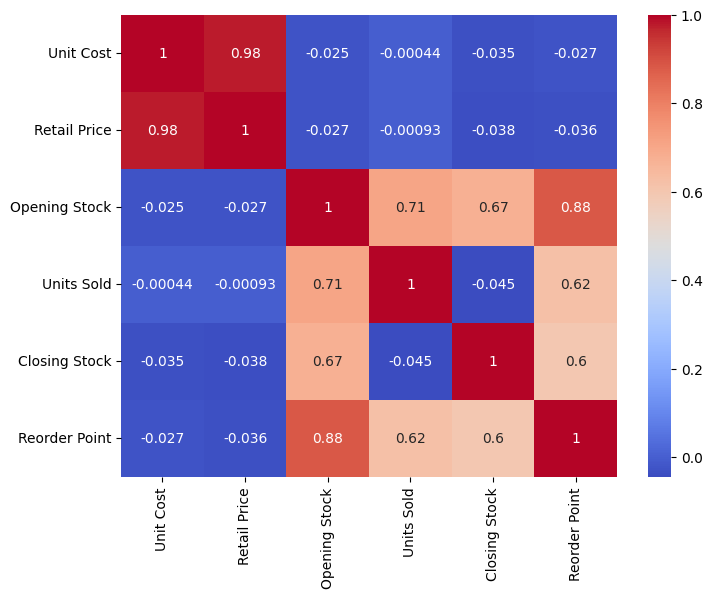

In [30]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

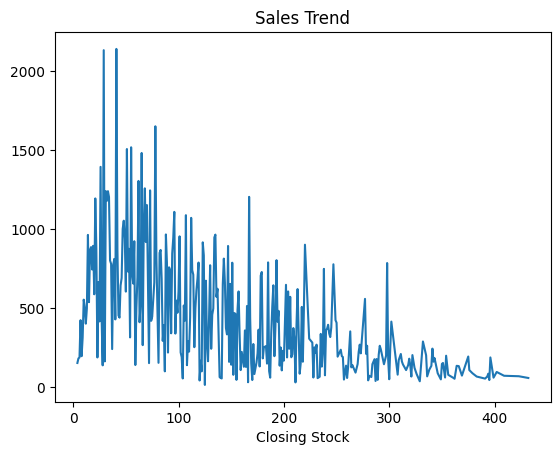

In [32]:
sales_trend = df.groupby('Closing Stock')['Units Sold'].sum()

sales_trend.plot(kind='line')
plt.title('Sales Trend')
plt.show()

In [15]:
print(df.columns)

Index(['Product ID', 'Product Name', 'Category', 'Supplier Name', 'Unit Cost',
       'Retail Price', 'Opening Stock', 'Units Sold', 'Closing Stock',
       'Reorder Point', 'Stock Status'],
      dtype='object')
